In [23]:
import cv2
import random
import insightface
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

In [3]:
df = pd.read_pickle("./embeddings-0312.pkl")

is_array_col = df['embedding'].apply(lambda x: isinstance(x, np.ndarray))

# convert back to float32
df['embedding'] = df['embedding'].apply(lambda x: x.astype(np.float32))

In [5]:
# img to embedding function

def img_to_embedding(img_path):

    # read img
    read_img = cv2.imread(img_path)

    # init face analysis app
    app = FaceAnalysis()

    # to prepare images 
    app.prepare(ctx_id=0)
    try:
        faces = app.get(read_img)[0]['embedding']
        return faces
    
    except Exception as e:
        print(f"Error in embedding function for {img_path}: {e}")
        return None

In [27]:
import glob
import os

root_folder = "/home/sho/insightface/gsi/img/sabrina"
image_paths = glob.glob(os.path.join(root_folder, "**", "*.JPG"), recursive=True)

# convert sabrina to emebddings
embeddings_data = []

for img_path in image_paths:
    try:
        embedding = img_to_embedding(img_path)
        if embedding is None:
            continue
        
        embeddings_data.append({
            "name":"Sabrina Ho",
            "ID":5749,
            "embedding": embedding,
            "embedding_type": type(embedding),
            "embedding_dtype": embedding.dtype,
            "embedding_size": embedding.size,
            "image_name": os.path.basename(img_path),
            "filepath": img_path
        })
    
    except Exception as e:
        print(f"Failed to process {img_path}: {e}")


/home/sho/anaconda3/envs/face-gen-notebook/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:118: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (64

In [28]:
df_sab = pd.DataFrame(embeddings_data)
df_sabrina = pd.concat([df, df_sab], ignore_index=True)
print(f"original df shape:{df.shape}")
print(f"df with sabrina shape:{df_sabrina.shape}")

df_sabrina.to_pickle("embeddings_sabrina.pkl")

original df shape:(13195, 8)
df with sabrina shape:(13199, 10)


# start live demo

In [29]:
# query on live sabrina
query_path =  '/home/sho/insightface/gsi/img/sabrina/demo.png'
emb_sab_query = img_to_embedding(query_path)

/home/sho/anaconda3/envs/face-gen-notebook/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:118: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (64

In [30]:
detector = insightface.model_zoo.get_model('/home/sho/.insightface/models/buffalo_l/w600k_r50.onnx')

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


In [43]:
# sim scores
similarities = []

for i in range(len(df_sabrina)):
    emb = df_sabrina['embedding'].iloc[i]
    sim = detector.compute_sim(emb_sab_query, emb)
    similarities.append(sim)

# top 10
top_k_indices = np.argsort(similarities)[::-1][:10]
top_k_scores = [similarities[i] for i in top_k_indices]
top_k_ids = [int(df_sabrina.iloc[i]['ID']) for i in top_k_indices]

print(f"top k person ID:{top_k_ids}")

top k person ID:[5749, 5749, 5749, 5749, 5708, 2340, 2612, 4684, 487, 380]


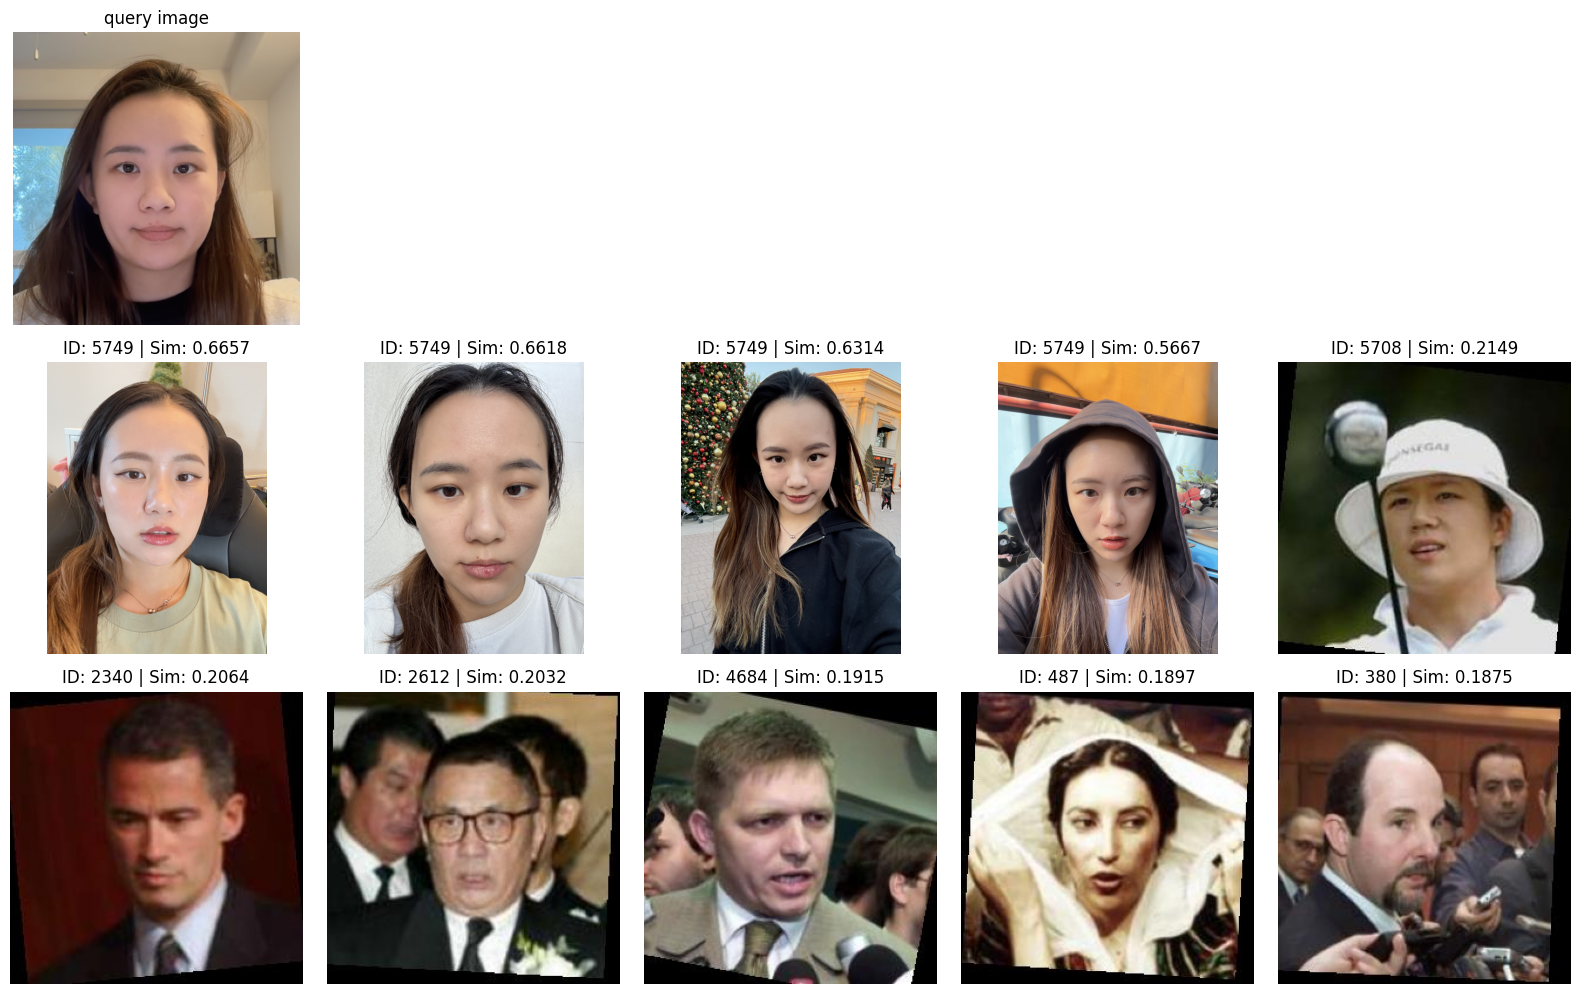

In [ ]:
# plot

rows = 2
cols = 5
fig = plt.figure(figsize=(16, 10))

# plot query
query_img = cv2.imread(query_path)
query_img_rgb = query_img[:, :, ::-1]

ax = fig.add_subplot(rows + 1, cols, 1)
ax.imshow(query_img_rgb)
ax.set_title("query image")
ax.axis("off")

for i in range(1, cols):
    ax = fig.add_subplot(rows + 1, cols, i + 1)
    ax.axis("off")

for idx, i in enumerate(top_k_indices):
    fp = df_sabrina.iloc[i]['filepath']
    read_img = cv2.imread(fp)
    read_img_rgb = read_img[:, :, ::-1]

    sim_score = top_k_scores[idx]

    ax = fig.add_subplot(rows + 1, cols, cols + idx + 1)  # start from row 2
    ax.imshow(read_img_rgb)
    ax.set_title(f"ID: {df_sabrina.iloc[i]['ID']} | Sim: {sim_score:.4f}")
    ax.axis("off")

plt.tight_layout()
plt.show()